In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import re
from glob import glob
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns

In [ ]:

dataset_path = "/content/drive/MyDrive/Audio_project/HW1_M"

audio_files = glob(os.path.join(dataset_path, "*.mp3"))

file_data = []

filename_pattern = re.compile(r"HW\d+_Q\d+_(\d+)_(male|female)", re.IGNORECASE)

for file_path in audio_files:
    filename = os.path.basename(file_path)
    match = filename_pattern.match(filename)

    if match:
        student_id, gender = match.groups()
        file_data.append([filename, file_path, student_id, gender.lower()])

df_audio = pd.DataFrame(file_data, columns=["Filename", "Filepath", "Student_ID", "Gender"])

df_audio.head()


,Filename,Filepath,Student_ID,Gender
0,HW1_Q5_810801072_Male.mp3,/content/drive/MyDrive/Audio_project/HW1_M/HW1...,810801072,male
1,HW1_Q3_810103262_male.mp3,/content/drive/MyDrive/Audio_project/HW1_M/HW1...,810103262,male
2,HW1_Q6_810600133_female.mp3,/content/drive/MyDrive/Audio_project/HW1_M/HW1...,810600133,female
3,HW1_Q4_159403005_male.mp3,/content/drive/MyDrive/Audio_project/HW1_M/HW1...,159403005,male
4,HW1_Q1_810102345_male.mp3,/content/drive/MyDrive/Audio_project/HW1_M/HW1...,810102345,male


In [ ]:
male_data = df_audio[df_audio["Gender"] == "male"]
female_data = df_audio[df_audio["Gender"] == "female"]

print("Number of Male Audio Files:", len(male_data))
print("Number of Female Audio Files:", len(female_data))


Number of Male Audio Files: 458
Number of Female Audio Files: 152


In [ ]:
grouped_by_student = df_audio[["Student_ID", "Filename"]].groupby("Student_ID").count().reset_index().sort_values("Filename", ascending=False)

print("Number of Unique Students:", len(grouped_by_student))

grouped_by_student = grouped_by_student.rename({"Filename": "Number of Files"}, axis = 1)
grouped_by_student



Number of Unique Students: 107


,Student_ID,Number of Files
6,610399205,7
0,151501033,6
63,810103140,6
74,810103241,6
72,810103222,6
...,...,...
87,810198554,4
93,810199459,3
75,810103262,3
73,810103224,3


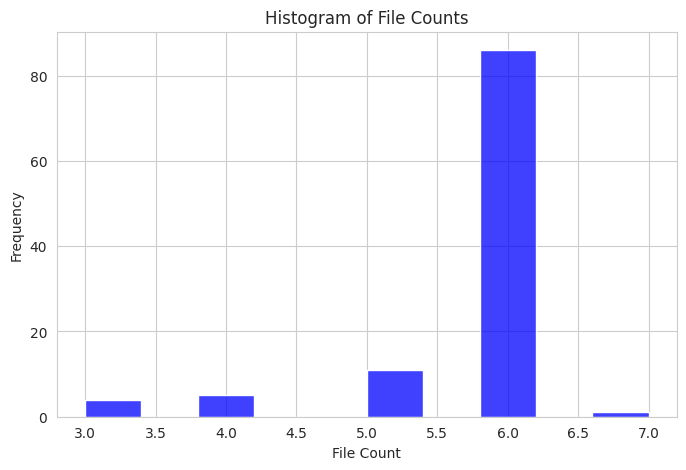

In [ ]:
sns.set_style("whitegrid")

plt.figure(figsize=(8, 5))
sns.histplot(grouped_by_student["Number of Files"], bins=10, color="blue")

plt.xlabel("File Count")
plt.ylabel("Frequency")
plt.title("Histogram of File Counts")

plt.show()

In [ ]:
from tqdm import tqdm
tqdm.pandas()

def bandpass_filter(y, sr, lowcut=80.0 , highcut=3500.0, order=5):
    nyquist = 0.5 * sr
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    y_filtered = lfilter(b, a, y)
    return y_filtered

def normalize_audio(y):
    return y / np.max(np.abs(y))

def segment_audio(y, sr, segment_length=2.0):
    segment_samples = int(segment_length * sr)
    return [y[i:i + segment_samples] for i in range(0, len(y), segment_samples) if len(y[i:i + segment_samples]) == segment_samples]

def preprocess_and_extract_features(file_path, n_mfcc=40, segment_length=2.0, target_sr=16000, max_length=60):

    y, sr = librosa.load(file_path, sr=None, duration=max_length)
    y = bandpass_filter(y, sr)
    y = resample(y, int(len(y) * target_sr / sr))
    sr = target_sr
    y = normalize_audio(y)
    segments = segment_audio(y, sr, segment_length)

    features = []
    for segment in segments:
        mfcc = librosa.feature.mfcc(y=segment, sr=sr, n_mfcc=n_mfcc).mean(axis=1)
        zcr = librosa.feature.zero_crossing_rate(segment).mean()
        rms = librosa.feature.rms(y=segment).mean()
        spectral_centroid = librosa.feature.spectral_centroid(y=segment, sr=sr).mean()
        spectral_bandwidth = librosa.feature.spectral_bandwidth(y=segment, sr=sr).mean()
        spectral_contrast = librosa.feature.spectral_contrast(y=segment, sr=sr).mean()
        features.append(np.hstack([mfcc, zcr, rms, spectral_centroid, spectral_bandwidth, spectral_contrast]))

    return np.array(features)

def balance_dataset(df):
    male_data = df[df["Gender"] == "male"]
    female_data = df[df["Gender"] == "female"]
    balanced_male_data = male_data.sample(len(female_data), random_state=42)
    balanced_df = pd.concat([balanced_male_data, female_data]).reset_index(drop=True)
    return balanced_df

def process_all_files(df, segment_length=2.0, target_sr=16000, max_length=60):
    features = []
    labels = []
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing files"):
        file_path = row["Filepath"]
        label = 1 if row["Gender"] == "female" else 0
        try:
            file_features = preprocess_and_extract_features(file_path, segment_length=segment_length, target_sr=target_sr, max_length=max_length)
            for feature in file_features:
                features.append(feature)
                labels.append(label)
        except Exception as e:
            print(f"Error processing file {file_path}: {e}")
    return np.array(features), np.array(labels)

In [ ]:
sample_file_path = df_audio.iloc[0]["Filepath"]
sample_features = preprocess_and_extract_features(sample_file_path)

print(f"Extracted Features Shape: {sample_features.shape}")

Extracted Features Shape: (30, 45)


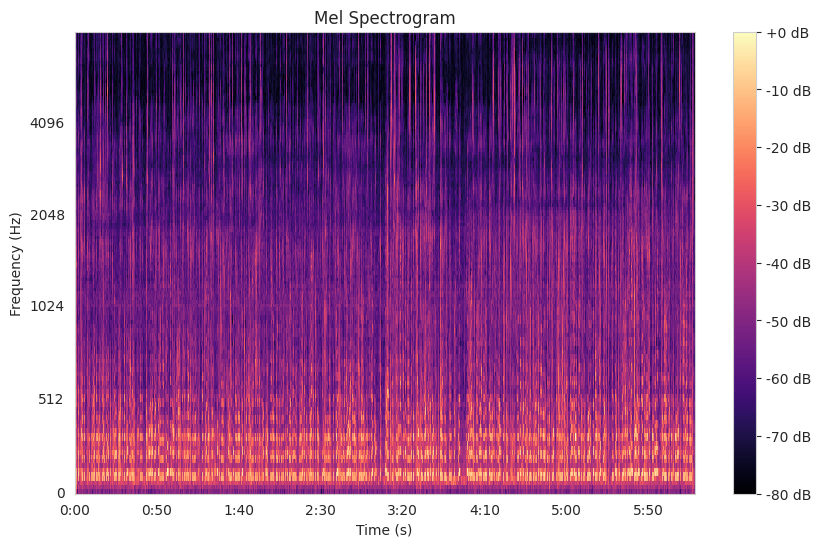

In [ ]:
plt.figure(figsize=(10, 6))
y, sr = librosa.load(sample_file_path, sr=None)
y_resampled = resample(y, int(len(y) * 16000 / sr))
sr = 16000
S = librosa.feature.melspectrogram(y=y_resampled, sr=sr)
librosa.display.specshow(librosa.power_to_db(S, ref=np.max), sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title("Mel Spectrogram")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.show()


In [ ]:
def select_random_voices(df, num_samples=3):
    return df.groupby("Student_ID", group_keys=False).apply(lambda x: x.sample(n=min(len(x), num_samples), random_state=42))

filtered_df_audio = select_random_voices(df_audio)
balanced_df = balance_dataset(filtered_df_audio)

id_gender_df = balanced_df[['Student_ID', 'Gender']].drop_duplicates()
train_ids, test_ids = train_test_split(id_gender_df['Student_ID'],  test_size=0.25, random_state=42, stratify=id_gender_df['Gender'])

train_df = balanced_df[balanced_df['Student_ID'].isin(train_ids)]
test_df = balanced_df[balanced_df['Student_ID'].isin(test_ids)]

assert len(set(train_df['Student_ID']).intersection(set(test_df['Student_ID']))) == 0, "ID Overlap detected!"


<ipython-input-21-a5b6132adbae>:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("Student_ID", group_keys=False).apply(lambda x: x.sample(n=min(len(x), num_samples), random_state=42))


In [ ]:

X_train, y_train = process_all_files(train_df)
X_test, y_test = process_all_files(test_df)



Processing files: 100%|██████████| 42/42 [01:19<00:00,  1.89s/it]


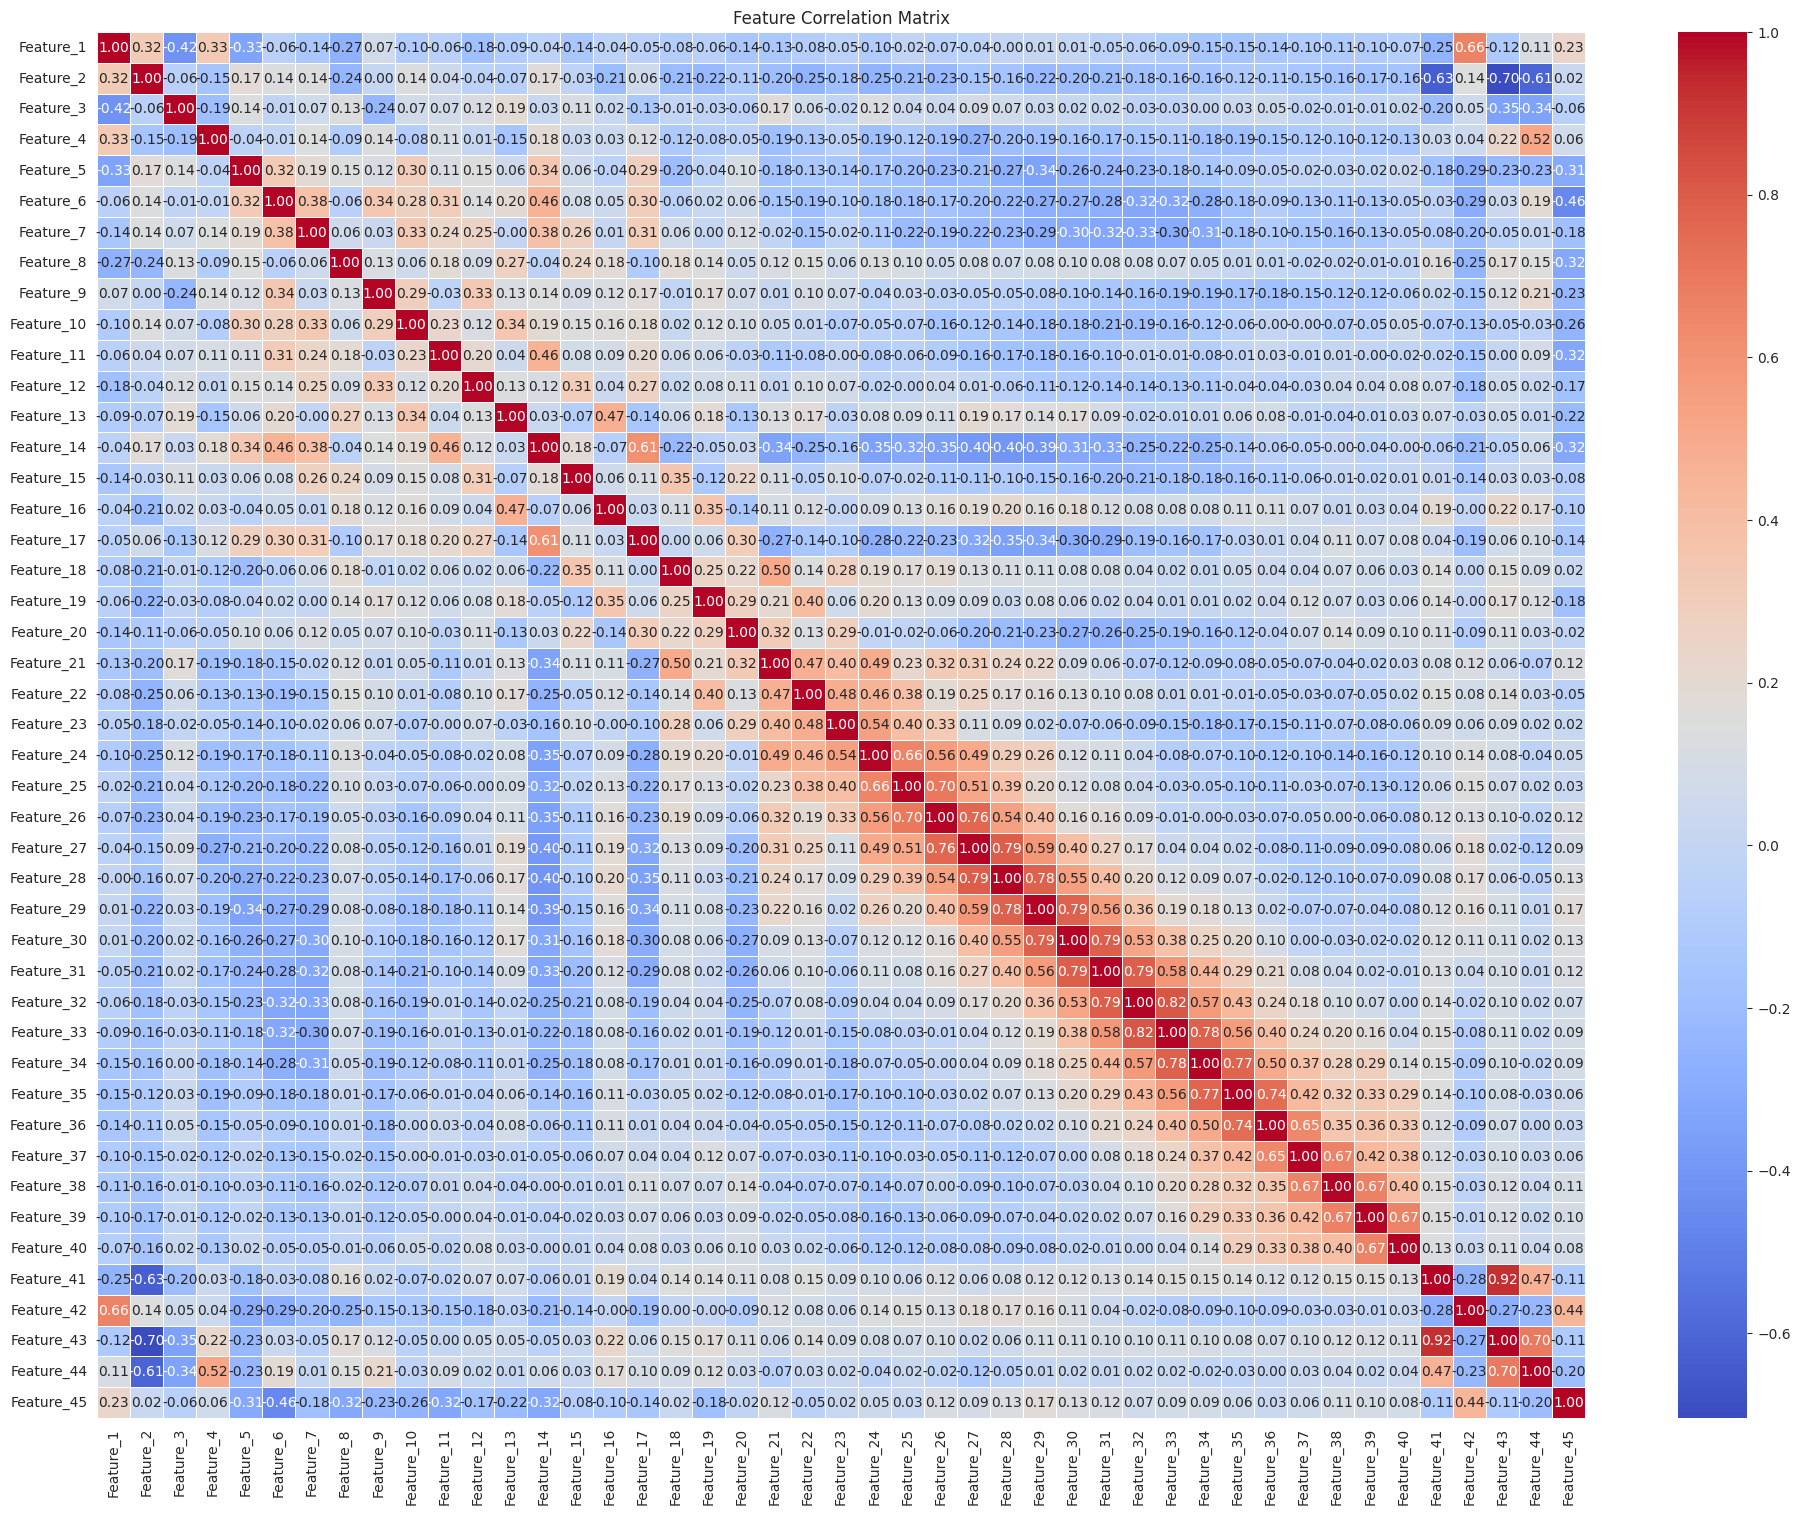

In [ ]:
import seaborn as sns

df_test = pd.DataFrame(X_train, columns=[f'Feature_{i+1}' for i in range(X_train.shape[1])])

corr_matrix = df_test.corr()
plt.figure(figsize=(24, 18))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

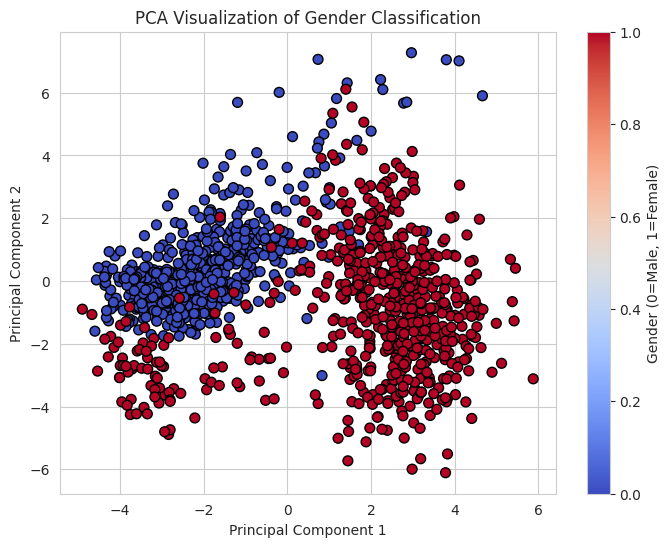

In [ ]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='coolwarm', edgecolor='k', s=50)
plt.title("PCA Visualization of Gender Classification")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Gender (0=Male, 1=Female)")
plt.show()


Training SVM...
SVM Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92       630
           1       0.95      0.89      0.92       630

    accuracy                           0.92      1260
   macro avg       0.92      0.92      0.92      1260
weighted avg       0.92      0.92      0.92      1260

Confusion Matrix:
[[599  31]
 [ 72 558]]
ROC AUC: 0.97


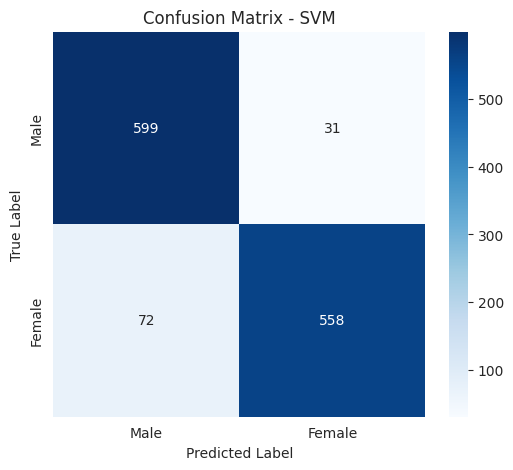


Training KNN...
KNN Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       630
           1       0.96      0.86      0.91       630

    accuracy                           0.91      1260
   macro avg       0.92      0.91      0.91      1260
weighted avg       0.92      0.91      0.91      1260

Confusion Matrix:
[[608  22]
 [ 90 540]]
ROC AUC: 0.93


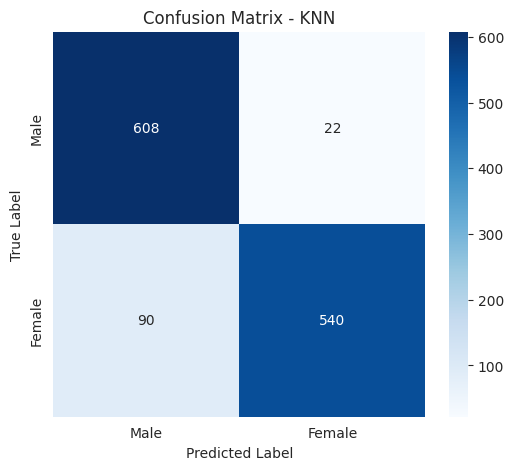


Training XGBoost...


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:04:00] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.94       630
           1       0.95      0.93      0.94       630

    accuracy                           0.94      1260
   macro avg       0.94      0.94      0.94      1260
weighted avg       0.94      0.94      0.94      1260

Confusion Matrix:
[[602  28]
 [ 46 584]]
ROC AUC: 0.98


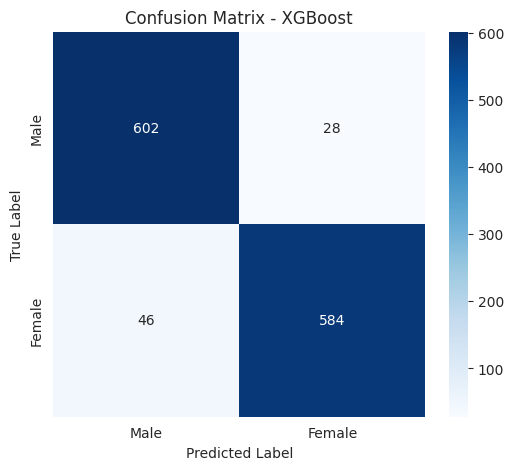


Training LogisticRegression...
LogisticRegression Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       630
           1       0.97      0.89      0.93       630

    accuracy                           0.93      1260
   macro avg       0.93      0.93      0.93      1260
weighted avg       0.93      0.93      0.93      1260

Confusion Matrix:
[[610  20]
 [ 67 563]]
ROC AUC: 0.97


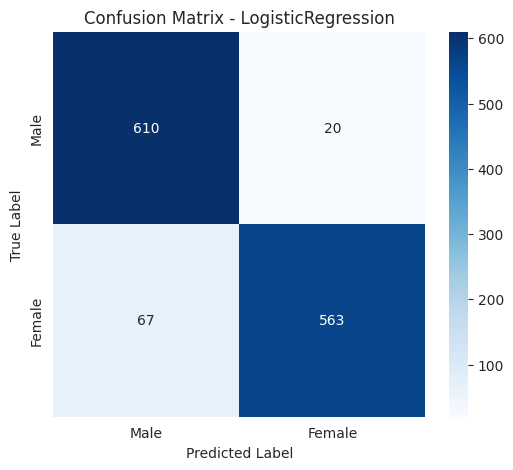

In [ ]:
from xgboost import XGBClassifier


models = {
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42),
    "LogisticRegression": LogisticRegression()
}

results = {}

for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None

    results[model_name] = {
        "Classification Report": report,
        "Confusion Matrix": cm,
        "ROC AUC": roc_auc
    }

    print(f"{model_name} Classification Report:")
    print(classification_report(y_test, y_pred))
    print(f"Confusion Matrix:\n{cm}")
    if roc_auc:
        print(f"ROC AUC: {roc_auc:.2f}")

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Male", "Female"], yticklabels=["Male", "Female"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        results[model_name]["ROC Curve"] = (fpr, tpr)




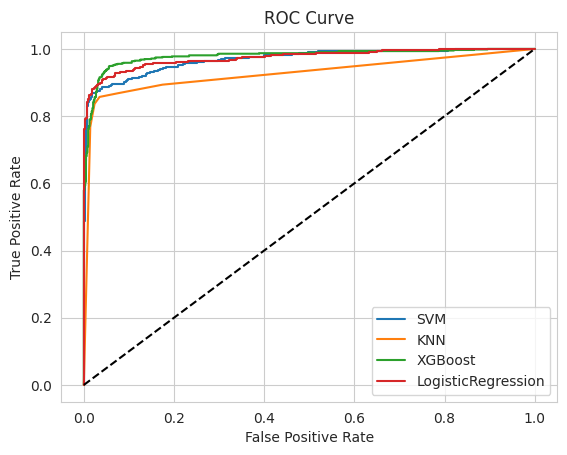

In [ ]:

for model_name, res in results.items():
    fpr, tpr = res.get("ROC Curve")
    plt.plot(fpr, tpr, label=model_name)

plt.plot([0, 1], [0, 1], "k--")
plt.title(f"ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()
